# **Projeto de Análise de Dados Climáticos no Brasil**

**Disciplina:** Linguagem de Programação — Análise e Visualização de Dados com Python

**Período analisado:** 2015 a 2024

**Base de dados:** `simulacao_clima_brasil.csv`

## **1. Introdução**



Este projeto tem como objetivo analisar dados climáticos do Brasil entre 2015 e 2024, buscando identificar padrões relacionados à temperatura, chuva, eventos extremos e sazonalidade.

A análise compara regiões e estados, investiga a evolução dos indicadores ao longo do tempo e culmina em um dashboard interativo desenvolvido com Streamlit.

## **2. Contextualização climática**



As mudanças climáticas e os eventos extremos afetam diferentes áreas da sociedade:

- **Agricultura:** secas, chuvas intensas e variações de temperatura influenciam a produtividade e o planejamento do plantio.
- **Abastecimento de água:** períodos de seca e de chuva intensa afetam a disponibilidade e a gestão dos recursos hídricos.
- **Energia:** a temperatura e o regime de chuvas influenciam a demanda e a geração de energia.
- **Saúde pública:** ondas de calor, umidade elevada e eventos extremos impactam a saúde da população.
- **Meio ambiente:** mudanças no clima alteram ecossistemas e aumentam riscos ambientais.
- **Qualidade de vida:** alagamentos, calor excessivo e desastres afetam o dia a dia nas cidades.

O monitoramento de indicadores climáticos permite identificar padrões ambientais, períodos críticos e tendências ao longo do tempo. Neste projeto, esse monitoramento é feito sobre uma **base de dados simulada**, o que será considerado na interpretação dos resultados.

## **3. Explicação da base**



A base de dados utilizada neste projeto é composta por registros climáticos simulados do Brasil, abrangendo o período de 2015 a 2024.

Cada registro apresenta informações relacionadas ao período da medição, à localização e às condições climáticas observadas. Entre as principais variáveis estão a temperatura média, temperatura máxima, temperatura mínima, volume de chuva, umidade, velocidade do vento, quantidade de eventos extremos e nível de alerta.

A base permite realizar análises temporais e comparações entre diferentes regiões, estados e cidades brasileiras. Essas características possibilitam investigar a evolução das condições climáticas, identificar períodos com maior ocorrência de eventos extremos e observar diferenças entre localidades.

As variáveis disponíveis na base são:

| Variável | Descrição |
|---|---|
| `ano` | Ano da medição |
| `mes` | Mês da medição |
| `data` | Data de referência |
| `regiao` | Região do Brasil |
| `uf` | Estado |
| `cidade` | Cidade monitorada |
| `temperatura_media` | Temperatura média |
| `temperatura_maxima` | Temperatura máxima |
| `temperatura_minima` | Temperatura mínima |
| `chuva_mm` | Volume de chuva em milímetros |
| `umidade` | Umidade relativa do ar |
| `velocidade_vento` | Velocidade média do vento |
| `eventos_extremos` | Quantidade de eventos extremos |
| `nivel_alerta` | Classificação do nível de alerta |

## **4. Leitura dos dados**

A base de dados foi carregada para o ambiente de análise utilizando a biblioteca Pandas. A leitura inicial permite verificar os registros disponíveis e analisar a estrutura do conjunto de dados utilizado no projeto.

In [7]:
import pandas as pd

df = pd.read_csv("simulacao_clima_brasil.csv")

df.head()

,ano,mes,data,regiao,uf,cidade,temperatura_media,temperatura_maxima,temperatura_minima,chuva_mm,umidade,velocidade_vento,eventos_extremos,nivel_alerta
0,2015,1,2015-01-01,Norte,AM,Manaus,27.9,34.7,22.5,16.3,42.8,31.5,1,Alto
1,2015,1,2015-01-01,Norte,PA,Belém,24.4,28.1,17.9,96.5,74.9,33.6,2,Médio
2,2015,1,2015-01-01,Norte,PA,Santarém,21.1,24.9,17.5,155.3,86.6,3.5,0,Crítico
3,2015,1,2015-01-01,Norte,RO,Porto Velho,25.5,29.7,21.3,137.5,89.3,16.7,1,Baixo
4,2015,1,2015-01-01,Norte,TO,Palmas,23.2,30.2,17.6,202.1,46.4,16.4,2,Médio


## **5. Limpeza e preparação**

A etapa de limpeza e preparação foi realizada para garantir que os dados estivessem adequados para as análises posteriores. Foram verificadas as informações ausentes, os registros duplicados e os tipos das variáveis utilizadas no projeto.

In [8]:
print("Valores ausentes:")
print(df.isnull().sum())

print("\nRegistros duplicados:")
print(df.duplicated().sum())

print("\nTipos das variáveis:")
print(df.dtypes)

Valores ausentes:
ano                   0
mes                   0
data                  0
regiao                0
uf                    0
cidade                0
temperatura_media     0
temperatura_maxima    0
temperatura_minima    0
chuva_mm              0
umidade               0
velocidade_vento      0
eventos_extremos      0
nivel_alerta          0
dtype: int64

Registros duplicados:
0

Tipos das variáveis:
ano                     int64
mes                     int64
data                   object
regiao                 object
uf                     object
cidade                 object
temperatura_media     float64
temperatura_maxima    float64
temperatura_minima    float64
chuva_mm              float64
umidade               float64
velocidade_vento      float64
eventos_extremos        int64
nivel_alerta           object
dtype: object


## **6. Engenharia de atributos**

Nesta etapa, são criadas novas informações a partir das variáveis existentes na base de dados, com o objetivo de facilitar as análises temporais e sazonais dos dados climáticos.

In [9]:
df["data"] = pd.to_datetime(df["data"])

df["ano"] = df["data"].dt.year
df["mes_numero"] = df["data"].dt.month
df["estacao"] = df["data"].dt.month.map({
    12: "Verão", 1: "Verão", 2: "Verão",
    3: "Outono", 4: "Outono", 5: "Outono",
    6: "Inverno", 7: "Inverno", 8: "Inverno",
    9: "Primavera", 10: "Primavera", 11: "Primavera"
})

df.head()

,ano,mes,data,regiao,uf,cidade,temperatura_media,temperatura_maxima,temperatura_minima,chuva_mm,umidade,velocidade_vento,eventos_extremos,nivel_alerta,mes_numero,estacao
0,2015,1,2015-01-01,Norte,AM,Manaus,27.9,34.7,22.5,16.3,42.8,31.5,1,Alto,1,Verão
1,2015,1,2015-01-01,Norte,PA,Belém,24.4,28.1,17.9,96.5,74.9,33.6,2,Médio,1,Verão
2,2015,1,2015-01-01,Norte,PA,Santarém,21.1,24.9,17.5,155.3,86.6,3.5,0,Crítico,1,Verão
3,2015,1,2015-01-01,Norte,RO,Porto Velho,25.5,29.7,21.3,137.5,89.3,16.7,1,Baixo,1,Verão
4,2015,1,2015-01-01,Norte,TO,Palmas,23.2,30.2,17.6,202.1,46.4,16.4,2,Médio,1,Verão


A análise exploratória permite observar as principais características dos dados climáticos antes da apresentação dos indicadores e gráficos. Nesta etapa, são analisadas as distribuições das variáveis de temperatura, chuva, umidade e eventos extremos, além das diferenças entre regiões e estados.

In [10]:
print("Estatísticas descritivas:")
display(
    df[
        [
            "temperatura_media",
            "temperatura_maxima",
            "temperatura_minima",
            "chuva_mm",
            "umidade",
            "eventos_extremos"
        ]
    ].describe()
)

print("\nMédias por região:")
display(
    df.groupby("regiao")[
        [
            "temperatura_media",
            "chuva_mm",
            "umidade",
            "eventos_extremos"
        ]
    ].mean()
)

Estatísticas descritivas:


,temperatura_media,temperatura_maxima,temperatura_minima,chuva_mm,umidade,eventos_extremos
count,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000
mean,24.993176,30.495360,19.971824,105.895293,66.413851,2.008559
std,3.922671,4.180402,4.111152,60.035600,18.270190,1.433019
min,11.400000,15.600000,5.700000,4.200000,35.000000,0.000000
25%,22.400000,27.700000,17.300000,61.500000,50.300000,1.000000
50%,25.000000,30.400000,19.950000,94.800000,66.550000,2.000000
75%,27.600000,33.200000,22.700000,140.500000,82.000000,3.000000
max,39.300000,45.400000,34.300000,491.500000,97.900000,9.000000



Médias por região:


,temperatura_media,chuva_mm,umidade,eventos_extremos
regiao,,,,
Centro-Oeste,25.091000,106.613833,65.423833,2.128333
Nordeste,24.878438,110.141979,66.619062,2.060417
Norte,25.003167,103.305667,66.178667,1.895000
Sudeste,24.967756,103.965256,66.450641,1.966026
Sul,25.111389,105.974028,67.081528,2.026389


## **7. KPIs**

Nesta etapa, são calculados os principais indicadores climáticos da base de dados, considerando a temperatura média nacional, o volume total de chuva, a cidade com maior temperatura média, o estado com maior volume de chuva, o total de eventos extremos e a umidade média.

In [11]:
temperatura_media_nacional = df["temperatura_media"].mean()
chuva_total = df["chuva_mm"].sum()

cidade_mais_quente = (
    df.groupby("cidade")["temperatura_media"]
    .mean()
    .idxmax()
)

estado_mais_chuvoso = (
    df.groupby("uf")["chuva_mm"]
    .sum()
    .idxmax()
)

total_eventos_extremos = df["eventos_extremos"].sum()
umidade_media = df["umidade"].mean()

print(f"Temperatura média nacional: {temperatura_media_nacional:.2f} °C")
print(f"Chuva total: {chuva_total:,.2f} mm")
print(f"Cidade com maior temperatura média: {cidade_mais_quente}")
print(f"Estado com maior volume de chuva: {estado_mais_chuvoso}")
print(f"Total de eventos extremos: {total_eventos_extremos:,.0f}")
print(f"Umidade média: {umidade_media:.2f}%")

Temperatura média nacional: 24.99 °C
Chuva total: 470,175.10 mm
Cidade com maior temperatura média: Vila Velha
Estado com maior volume de chuva: RJ
Total de eventos extremos: 8,918
Umidade média: 66.41%


## **8. Gráficos**

Nesta etapa, são apresentados gráficos para analisar os principais padrões dos dados climáticos. As análises consideram a evolução da temperatura e da chuva ao longo do tempo, as diferenças entre estados e regiões, a ocorrência de eventos extremos, a sazonalidade e a relação entre temperatura e chuva.

**Temperatura média ao longo do tempo**

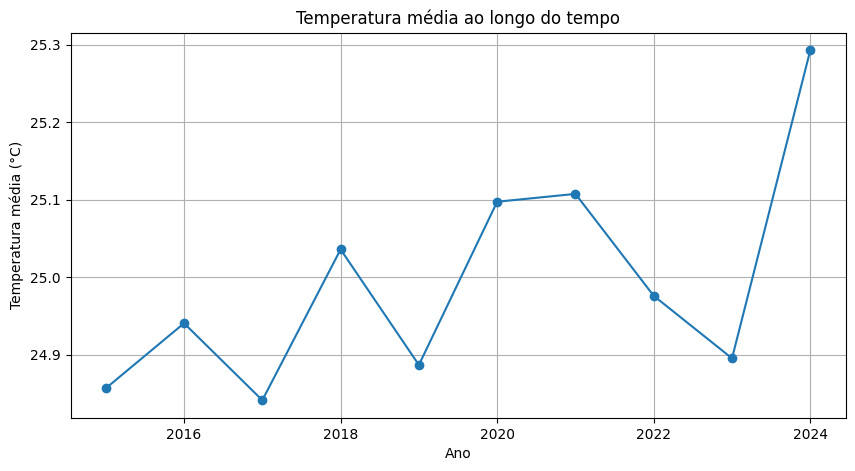

In [12]:
import matplotlib.pyplot as plt

temperatura_ano = df.groupby("ano")["temperatura_media"].mean()

plt.figure(figsize=(10, 5))
plt.plot(temperatura_ano.index, temperatura_ano.values, marker="o")

plt.title("Temperatura média ao longo do tempo")
plt.xlabel("Ano")
plt.ylabel("Temperatura média (°C)")
plt.grid(True)
plt.show()

### **Chuva total ao longo do tempo**

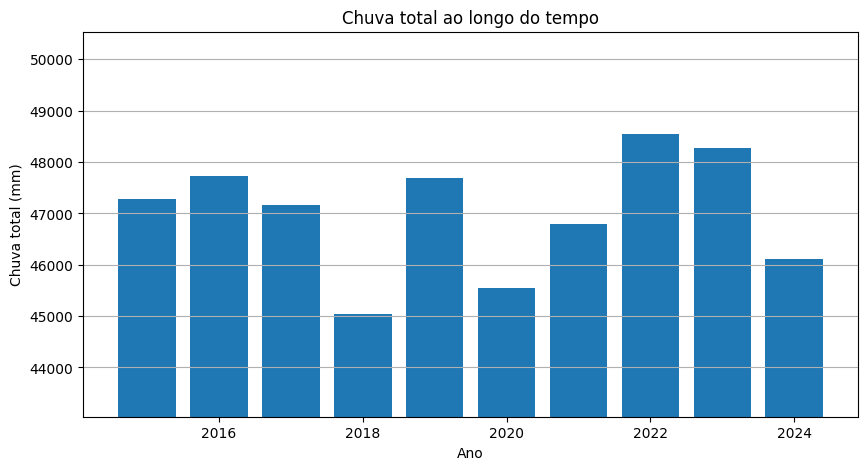

In [13]:
chuva_ano = df.groupby("ano")["chuva_mm"].sum()

plt.figure(figsize=(10, 5))
plt.bar(chuva_ano.index, chuva_ano.values)

plt.title("Chuva total ao longo do tempo")
plt.xlabel("Ano")
plt.ylabel("Chuva total (mm)")

plt.ylim(chuva_ano.min() - 2000, chuva_ano.max() + 2000)

plt.grid(axis="y")
plt.show()

### **Volume de chuva por estado**

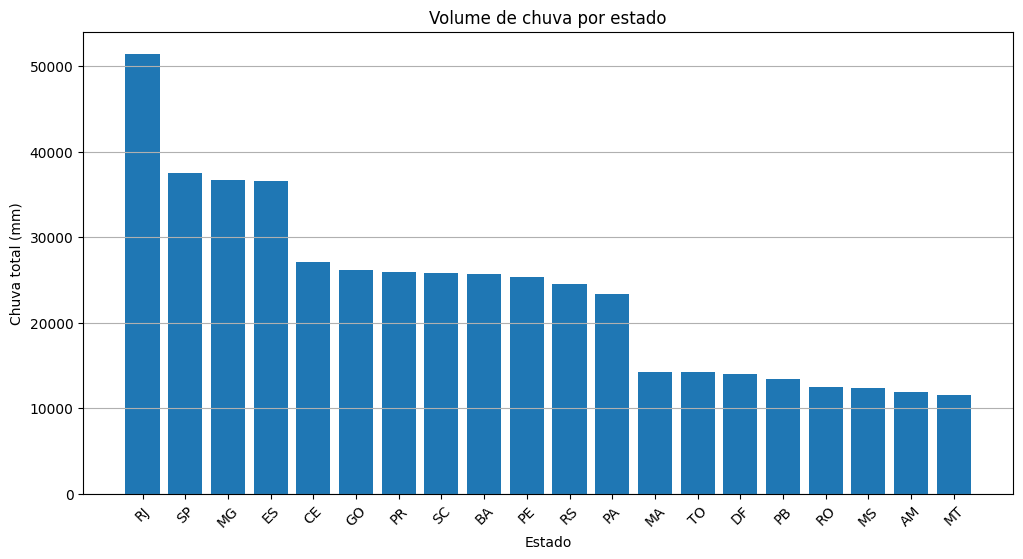

In [14]:
chuva_estado = (
    df.groupby("uf")["chuva_mm"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(chuva_estado.index, chuva_estado.values)

plt.title("Volume de chuva por estado")
plt.xlabel("Estado")
plt.ylabel("Chuva total (mm)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

### **Temperatura média por região**

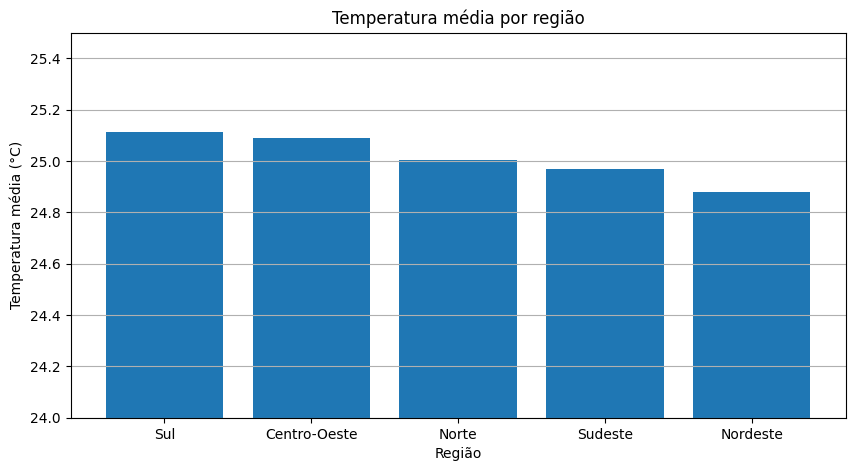

In [15]:
temperatura_regiao = (
    df.groupby("regiao")["temperatura_media"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
plt.bar(temperatura_regiao.index, temperatura_regiao.values)

plt.title("Temperatura média por região")
plt.xlabel("Região")
plt.ylabel("Temperatura média (°C)")

plt.ylim(24, 25.5)

plt.grid(axis="y")
plt.show()

### **Eventos extremos ao longo do tempo**

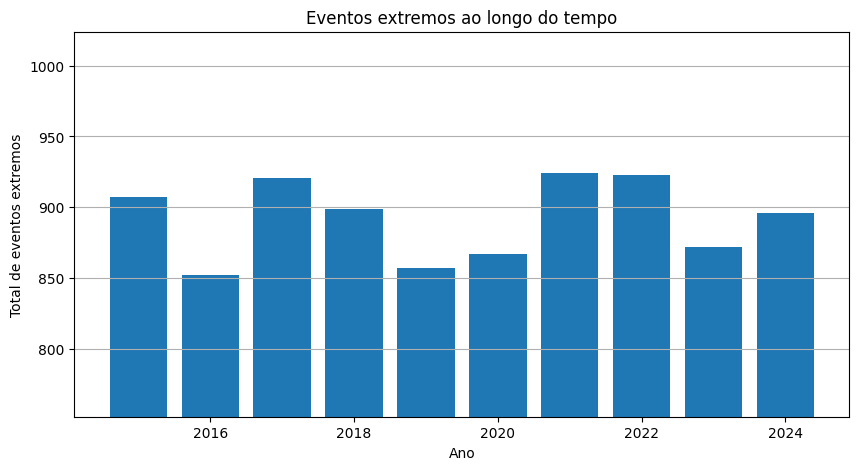

In [16]:
eventos_ano = df.groupby("ano")["eventos_extremos"].sum()

plt.figure(figsize=(10, 5))
plt.bar(eventos_ano.index, eventos_ano.values)

plt.title("Eventos extremos ao longo do tempo")
plt.xlabel("Ano")
plt.ylabel("Total de eventos extremos")

plt.ylim(eventos_ano.min() - 100, eventos_ano.max() + 100)

plt.grid(axis="y")
plt.show()

### **Temperatura média por mês e ano**

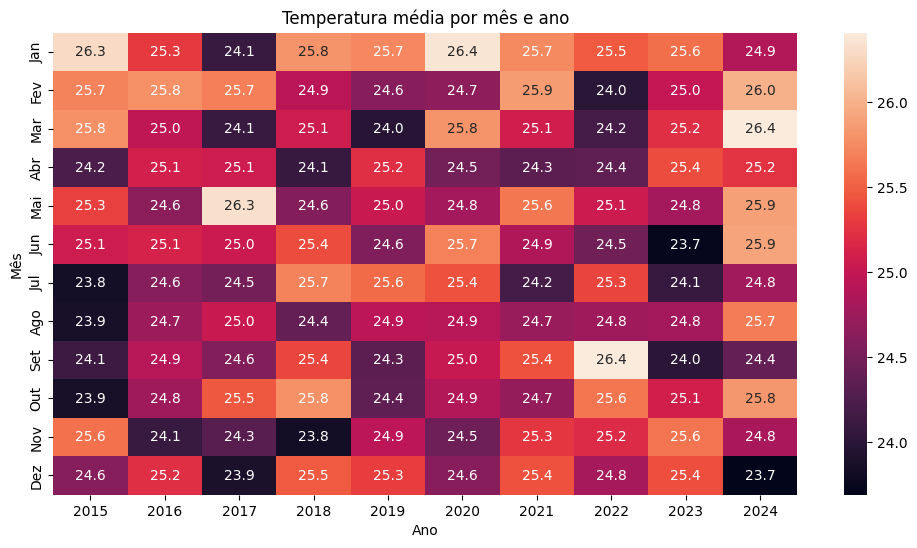

In [17]:
import seaborn as sns

meses = [
    "Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
    "Jul", "Ago", "Set", "Out", "Nov", "Dez"
]

temperatura_mensal = df.pivot_table(
    values="temperatura_media",
    index="mes",
    columns="ano",
    aggfunc="mean"
)

temperatura_mensal.index = meses

plt.figure(figsize=(12, 6))

sns.heatmap(
    temperatura_mensal,
    annot=True,
    fmt=".1f"
)

plt.title("Temperatura média por mês e ano")
plt.xlabel("Ano")
plt.ylabel("Mês")
plt.show()

### **Temperatura média x chuva**

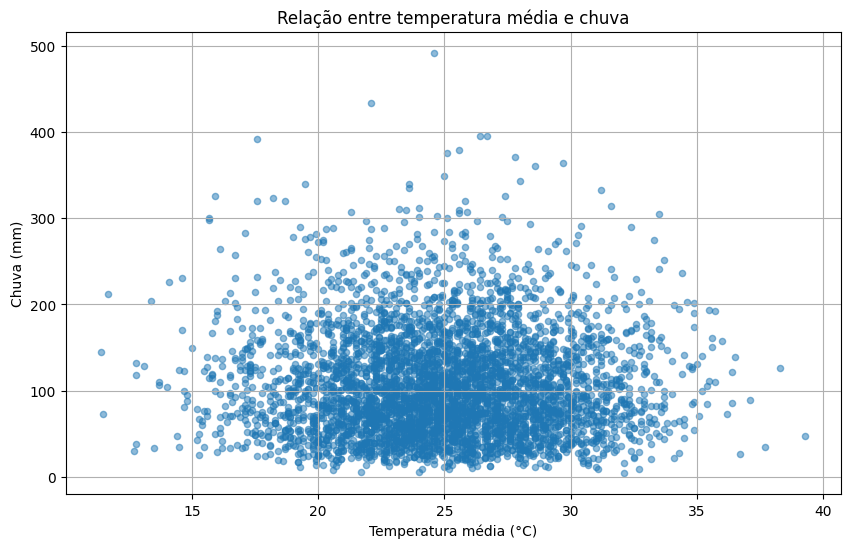

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["temperatura_media"],
    df["chuva_mm"],
    alpha=0.5,
    s=20
)

plt.title("Relação entre temperatura média e chuva")
plt.xlabel("Temperatura média (°C)")
plt.ylabel("Chuva (mm)")

plt.grid(True)
plt.show()

##**9. Interpretação dos resultados**

Os resultados obtidos permitem observar diferentes características dos dados climáticos analisados entre 2015 e 2024.

A temperatura média apresentou variações ao longo dos anos, com os maiores valores registrados em 2024. Na comparação entre as regiões, a região Sul apresentou a maior temperatura média, seguida pelo Centro-Oeste, Norte, Sudeste e Nordeste.

Em relação às chuvas, o maior volume total anual foi registrado em 2022, enquanto 2018 apresentou o menor volume entre os anos analisados. Na comparação entre os estados, o Rio de Janeiro apresentou o maior volume total de chuva na base analisada.

A ocorrência de eventos extremos apresentou variações entre os anos, com os maiores totais registrados em 2021 e 2022. No período analisado, foram contabilizados 8.918 eventos extremos.

A análise mensal permite observar variações sazonais nas temperaturas. Os meses de janeiro e fevereiro apresentaram as maiores médias de temperatura, enquanto agosto apresentou uma das menores médias observadas.

Por fim, o gráfico de dispersão entre temperatura média e chuva mostra uma grande concentração de registros em diferentes níveis de chuva e temperatura. A correlação calculada entre as duas variáveis foi próxima de zero, indicando que, nesta base, não foi observada uma relação linear relevante entre temperatura média e volume de chuva.

## **10. Conclusão**

A análise dos dados climáticos do Brasil entre 2015 e 2024 permitiu observar variações de temperatura, chuva, eventos extremos e padrões sazonais.

Os resultados também possibilitaram comparar diferentes regiões e estados, identificar períodos com maiores volumes de chuva e observar a distribuição dos eventos extremos ao longo do período analisado.

Dessa forma, o projeto permitiu organizar, analisar e visualizar os dados climáticos de maneira estruturada, contribuindo para a compreensão dos padrões presentes na base de dados e para a comunicação dos principais resultados da análise.